In [99]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('entrancetest.xlsx')

print(df.head())
print("Số dòng:")
print(df.shape[0])
print("Số cột:")
print(df.shape[1])
print("Kích thước của dataset:")
print(df.shape)
print(df.dtypes)

   toankc  vankc  anhkc  chuyen                          status
0    3.40   6.00    6.0    3.50  Khoa học Tự nhiên và Công nghệ
1    7.75   6.25    8.0    4.10                 Khoa học Xã hội
2    9.25   5.50    6.9    5.25                     Chuyên Toán
3    3.95   5.25    7.3    5.00                 Khoa học Xã hội
4    6.80   6.00    7.8    8.25  Khoa học Tự nhiên và Công nghệ
Số dòng:
999
Số cột:
5
Kích thước của dataset:
(999, 5)
toankc    float64
vankc     float64
anhkc     float64
chuyen    float64
status        str
dtype: object


In [100]:
cols = ['toankc', 'vankc', 'anhkc', 'chuyen']
statistic = pd.DataFrame()
for col in cols:
    statistic.loc[col, 'Mean'] = df[col].mean()
    statistic.loc[col, 'Median'] = df[col].median()
    statistic.loc[col, 'Mode'] = df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
    statistic.loc[col, 'Variance'] = df[col].var()
    statistic.loc[col, 'Std'] = df[col].std()
    statistic.loc[col, 'Min'] = df[col].min()
    statistic.loc[col, 'Max'] = df[col].max()
    statistic.loc[col, 'Q1 (25%)'] = df[col].quantile(0.25)
    statistic.loc[col, 'Q3 (75%)'] = df[col].quantile(0.75)
    statistic.loc[col, 'IQR'] = df[col].quantile(0.75) - df[col].quantile(0.25)

print(statistic.round(4))
print(df[cols].describe())

          Mean  Median  Mode  Variance     Std   Min   Max  Q1 (25%)  \
toankc  6.8187    7.00   8.5    3.0372  1.7428  2.25  10.0     5.550   
vankc   5.7204    5.75   6.0    0.6561  0.8100  2.25   8.0     5.250   
anhkc   7.4524    7.70   8.2    1.6676  1.2914  3.10   9.8     6.600   
chuyen  5.2910    5.20   5.0    2.2201  1.4900  2.10  10.0     4.225   

        Q3 (75%)    IQR  
toankc      8.05  2.500  
vankc       6.25  1.000  
anhkc       8.50  1.900  
chuyen      6.25  2.025  
           toankc       vankc       anhkc      chuyen
count  999.000000  999.000000  999.000000  999.000000
mean     6.818719    5.720350    7.452352    5.291011
std      1.742758    0.809988    1.291351    1.489992
min      2.250000    2.250000    3.100000    2.100000
25%      5.550000    5.250000    6.600000    4.225000
50%      7.000000    5.750000    7.700000    5.200000
75%      8.050000    6.250000    8.500000    6.250000
max     10.000000    8.000000    9.800000   10.000000


Nhận xét: Histogram thực tế có đỉnh lệch phải so với normal distribution (nhiều điểm cao hơn)
Phần đuôi của dữ liệu thật dài hơn của phân phối chuẩn
Kết luận, dữ liệu chỉ khớp tương đối so với normal distribution, bởi vì đây là danh sách học sinh đậu (đã lọc data) nên điểm trung bình sẽ cao hơn điểm trung bình thật sự của thí sinh thi vào trường. Và đề thi thì có điểm sàn 0 và điểm trần 10 nên outlier không được chạy tự do như iris (đo lường các mẫu vật), đồng thời thì dữ liệu chưa đủ lớn như thi THPTQG(100K mẫu) nên phân phối gần như không thể chuẩn.
P/S: Không thể có điểm nhỏ hơn 2 vì điểm liệt của trường là 2 cho mọi môn, đây cũng là một giới hạn của dataset này

In [101]:
grouped_stats = df.groupby('status')[cols].agg(['mean', 'std'])
print(grouped_stats.round(4))


                                toankc           vankc           anhkc  \
                                  mean     std    mean     std    mean   
status                                                                   
Chuyên Anh                      7.1803  1.6272  5.8784  0.8084  8.9578   
Chuyên Hóa                      8.0521  1.0209  5.9043  0.7724  8.0447   
Chuyên Lý                       7.4431  1.2610  5.6045  0.7200  7.2373   
Chuyên Sinh                     6.6256  1.4357  5.8556  0.6560  7.4222   
Chuyên Tin                      7.5112  1.4312  5.5367  0.7739  7.6673   
Chuyên Toán                     9.2239  0.7321  5.7908  0.6867  7.4467   
Chuyên Văn                      6.3682  1.2409  6.5864  0.5838  7.6200   
Khoa học Tự nhiên và Công nghệ  6.5220  1.5776  5.4750  0.7997  6.5977   
Khoa học Xã hội                 5.5893  1.4480  5.7935  0.7978  7.9512   

                                        chuyen          
                                   std    mean     std

Chuyên toán, chuyên anh, chuyên văn có điểm môn thường tương ứng cao nhất, hợp với dự đoán. Điểm chuyên cao nhất là của lớp chuyên lý với độ lệch chuẩn khá thấp so với mặt bằng chung (<1). Hai lớp chuyên khtn và khxh có điểm thi trung bình thấp nhất, còn môn có năng lực thí sinh trúng tuyển dao động lớn nhất là chuyên tin...

{'TOANKC'}
  - Skewness (độ lệch): -0.2453
  - Kurtosis (độ nhọn): -0.5047
  - Normality test p-value: 0.0000
  - Không có phân phối chuẩn (p < 0.05)
  - Phân phối tương đối đối xứng
{'VANKC'}
  - Skewness (độ lệch): -0.4617
  - Kurtosis (độ nhọn): 0.5580
  - Normality test p-value: 0.0000
  - Không có phân phối chuẩn (p < 0.05)
  - Phân phối tương đối đối xứng
{'ANHKC'}
  - Skewness (độ lệch): -0.6644
  - Kurtosis (độ nhọn): -0.2060
  - Normality test p-value: 0.0000
  - Không có phân phối chuẩn (p < 0.05)
  - Phân phối lệch trái (skewness = -0.66)
{'CHUYEN'}
  - Skewness (độ lệch): 0.2391
  - Kurtosis (độ nhọn): -0.4160
  - Normality test p-value: 0.0000
  - Không có phân phối chuẩn (p < 0.05)
  - Phân phối tương đối đối xứng


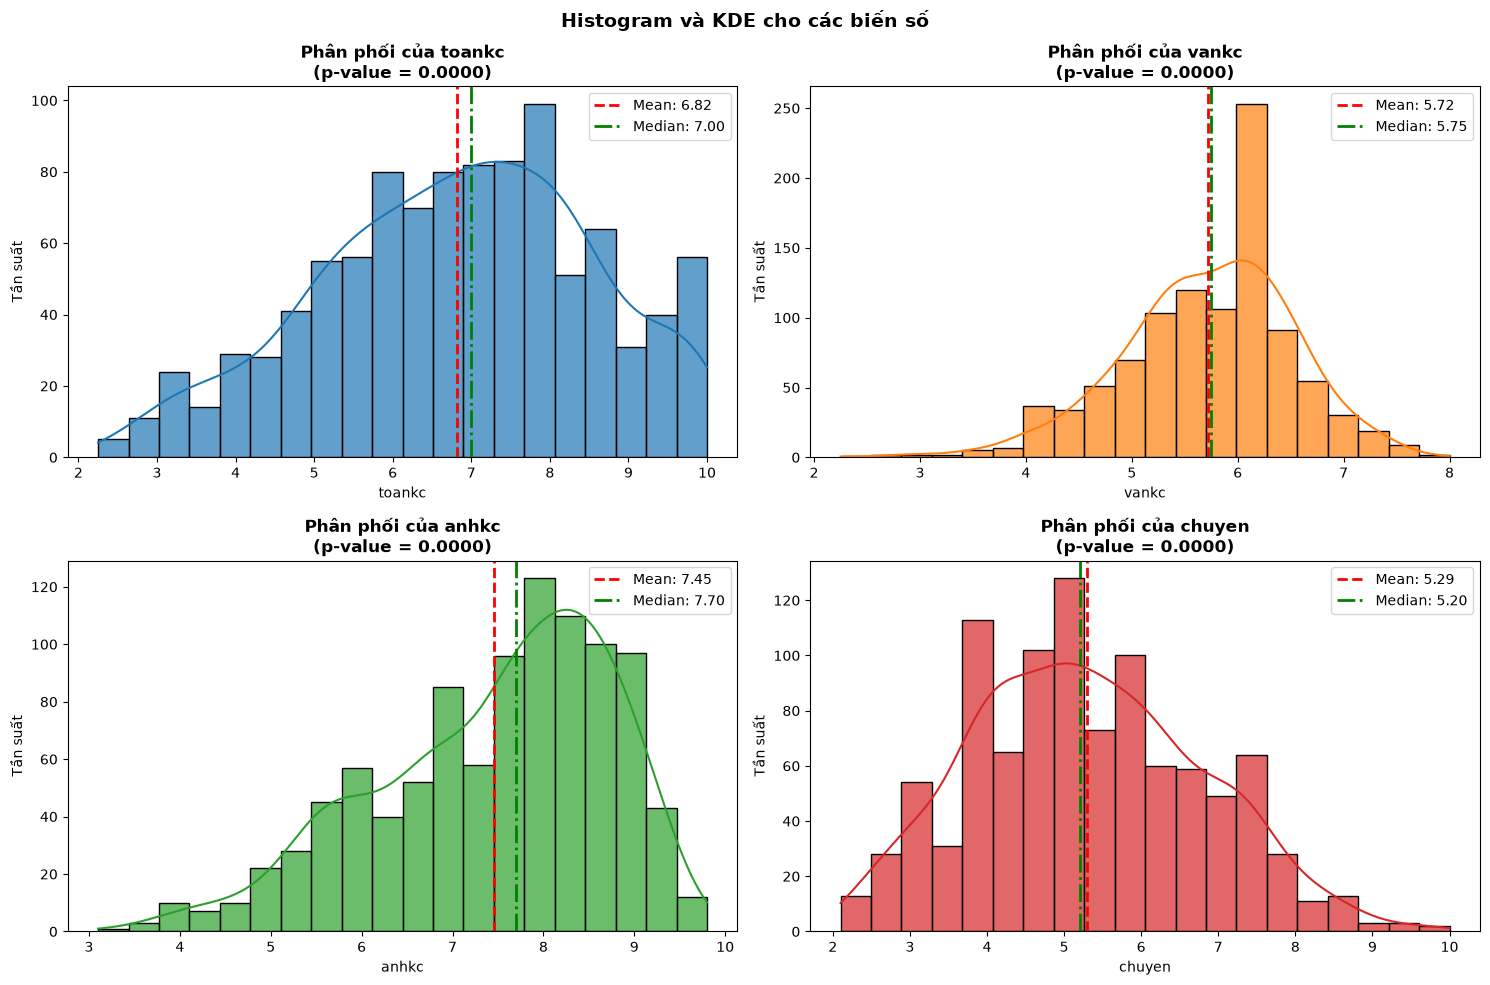

In [102]:

cols = ['toankc', 'vankc', 'anhkc', 'chuyen']
classname = 'status'

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(cols):
    # Histogram và KDE
    sns.histplot(df[col], kde=True, ax=axes[idx], bins=20, color=f'C{idx}', alpha=0.7)
    
    # Thêm mean và median
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='green', linestyle='-.', linewidth=2, label=f'Median: {median_val:.2f}')
    
    # Kiểm tra phân phối chuẩn
    from scipy import stats
    stat, p_value = stats.normaltest(df[col])
    
    axes[idx].set_title(f'Phân phối của {col}\n(p-value = {p_value:.4f})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Tần suất')
    axes[idx].legend()
    
    # Nhận xét hình dạng phân phối
    skewness = df[col].skew()
    kurtosis = df[col].kurtosis()
    print({col.upper()})
    print(f"  - Skewness (độ lệch): {skewness:.4f}")
    print(f"  - Kurtosis (độ nhọn): {kurtosis:.4f}")
    print(f"  - Normality test p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print(f"  - Không có phân phối chuẩn (p < 0.05)")
    else:
        print(f"  - Có phân phối chuẩn (p >= 0.05)")
    
    if abs(skewness) < 0.5:
        print(f"  - Phân phối tương đối đối xứng")
    elif skewness > 0.5:
        print(f"  - Phân phối lệch phải (skewness = {skewness:.2f})")
    else:
        print(f"  - Phân phối lệch trái (skewness = {skewness:.2f})")

plt.suptitle('Histogram và KDE cho các biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\PHUC\AppData\Local\Temp\ipykernel_47560\4284376821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, order=classname,


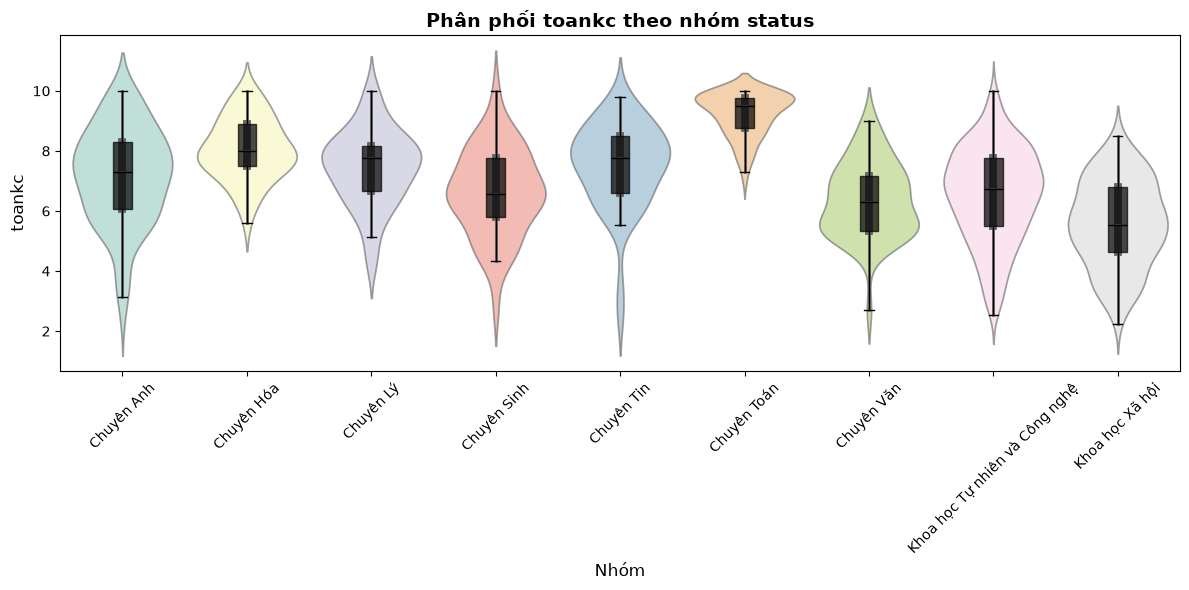

C:\Users\PHUC\AppData\Local\Temp\ipykernel_47560\4284376821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, order=classname,


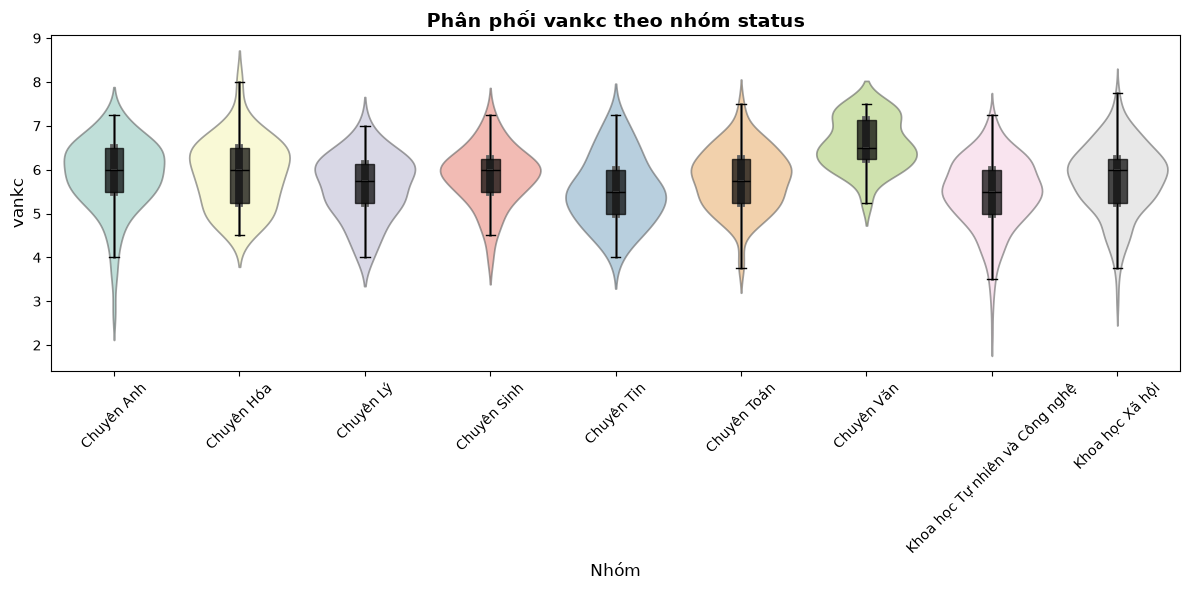

C:\Users\PHUC\AppData\Local\Temp\ipykernel_47560\4284376821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, order=classname,


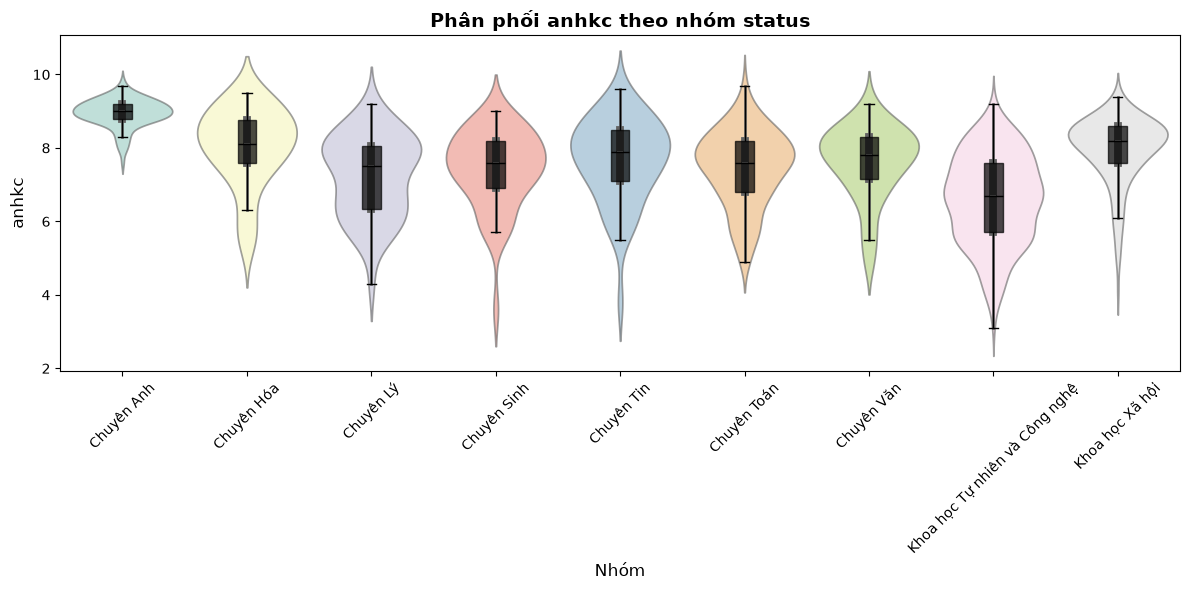

C:\Users\PHUC\AppData\Local\Temp\ipykernel_47560\4284376821.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='status', y=col, order=classname,


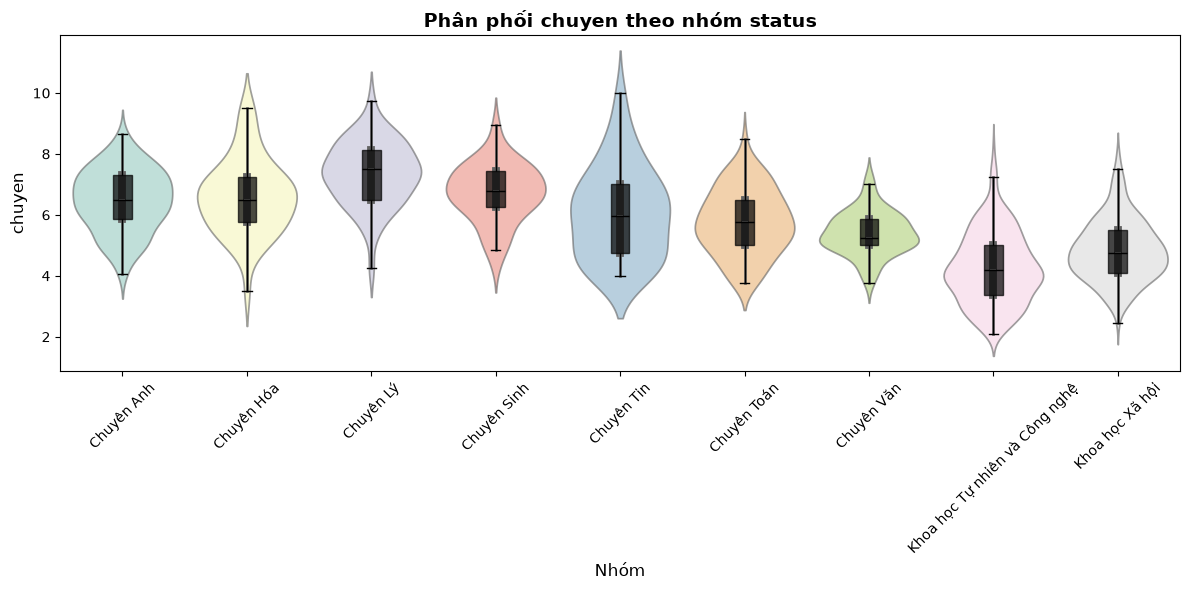

In [103]:
cols = ['toankc', 'vankc', 'anhkc', 'chuyen']
classname = sorted(df['status'].unique())

for col in cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.violinplot(data=df, x='status', y=col, order=classname,
                   ax=ax, palette='Set3', alpha=0.6)
    
    sns.boxplot(data=df, x='status', y=col, order=classname,
                ax=ax, width=0.15, showfliers=False,
                color='black', boxprops=dict(alpha=0.7))
    
    ax.set_title(f'Phân phối {col} theo nhóm status', 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Nhóm', fontsize=12)
    ax.set_ylabel(col, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

P/S: Lower whisker của các dữ liệu này có thể xuống dưới 2(điểm liệt) vì whiskers là tính toán lý thuyết chứ thực tế không có con điểm nào nhỏ hơn hoặc bằng 2

Mean thực tế: 6.82
Std thực tế: 1.74


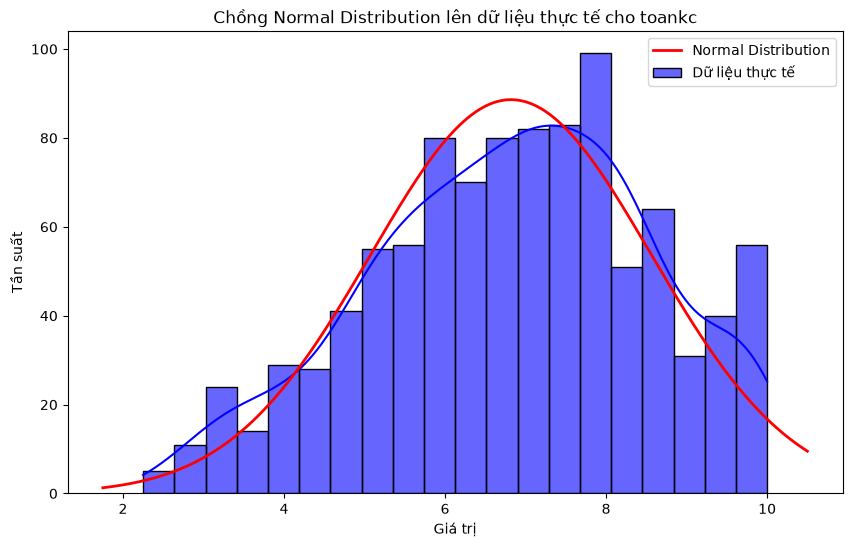

In [104]:
selected_col = 'toankc'
mean_actual = df[selected_col].mean()
std_actual = df[selected_col].std()
print(f"Mean thực tế: {mean_actual:.2f}")
print(f"Std thực tế: {std_actual:.2f}")

np.random.seed(42)
simulated_data = np.random.normal(loc=mean_actual, scale=std_actual, size=len(df))

from scipy.stats import norm

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram dữ liệu thực
sns.histplot(df[selected_col], kde=True, ax=ax, bins=20, 
             color='blue', alpha=0.6, label='Dữ liệu thực tế')

# Đường PDF lý thuyết
x = np.linspace(df[selected_col].min() - 0.5, df[selected_col].max() + 0.5, 1000)
pdf = norm.pdf(x, mean_actual, std_actual)

# Scale PDF để khớp với histogram
bin_width = (df[selected_col].max() - df[selected_col].min()) / 20
ax.plot(x, pdf * len(df) * bin_width, 'r-', linewidth=2, label='Normal Distribution')

ax.set_title(f'Chồng Normal Distribution lên dữ liệu thực tế cho {selected_col}')
ax.set_xlabel('Giá trị')
ax.set_ylabel('Tần suất')
ax.legend()
plt.show()

Nhận xét: Histogram thực tế có đỉnh lệch phải so với normal distribution (nhiều điểm cao hơn)
Phần đuôi của dữ liệu thật dài hơn của phân phối chuẩn
Kết luận, dữ liệu chỉ khớp tương đối so với normal distribution, bởi vì đây là danh sách học sinh đậu (đã lọc data) nên điểm trung bình sẽ cao hơn điểm trung bình thật sự của thí sinh thi vào trường. Và đề thi thì có điểm sàn 0 và điểm trần 10 nên outlier không được chạy tự do như iris (đo lường các mẫu vật), đồng thời thì dữ liệu chưa đủ lớn như thi THPTQG(100K mẫu) nên phân phối gần như không thể chuẩn.
P/S: Không thể có điểm nhỏ hơn 2 vì điểm liệt của trường là 2 cho mọi môn, đây cũng là một giới hạn của dataset này

        toankc   vankc   anhkc  chuyen
toankc  3.0372  0.0325  0.1596  0.0874
vankc   0.0325  0.6561  0.1316  0.0129
anhkc   0.1596  0.1316  1.6676  0.4640
chuyen  0.0874  0.0129  0.4640  2.2201
        toankc   vankc   anhkc  chuyen
toankc  1.0000  0.0230  0.0709  0.0337
vankc   0.0230  1.0000  0.1258  0.0107
anhkc   0.0709  0.1258  1.0000  0.2411
chuyen  0.0337  0.0107  0.2411  1.0000


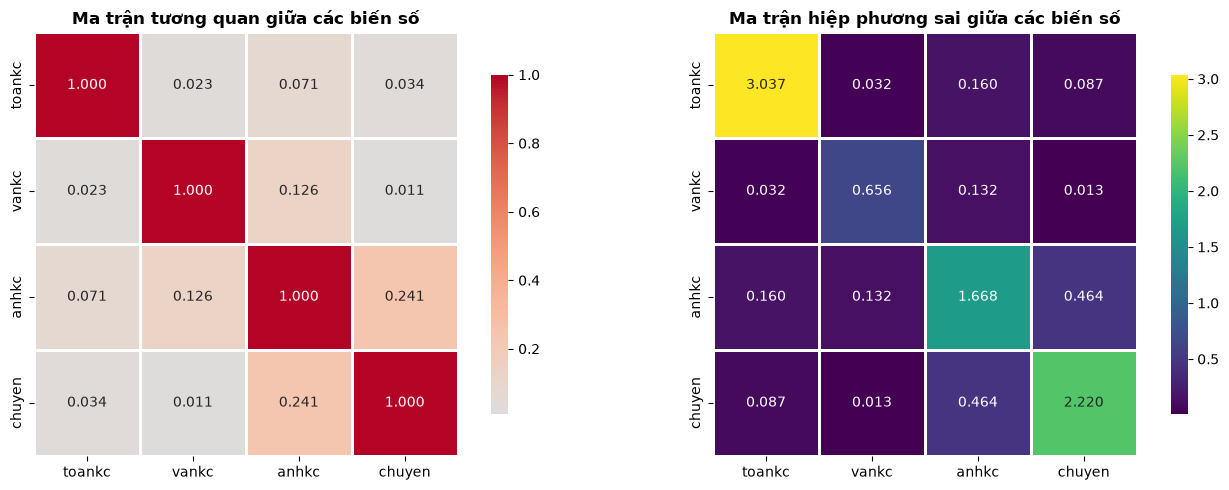

In [105]:
data_corr = df[cols]

# Ma trận hiệp phương sai
cov_matrix = data_corr.cov()
print(cov_matrix.round(4))
# Ma trận tương quan
corr_matrix = data_corr.corr()
print(corr_matrix.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap tương quan
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, 
            fmt='.3f', ax=axes[0])
axes[0].set_title('Ma trận tương quan giữa các biến số', fontsize=12, fontweight='bold')

# Heatmap hiệp phương sai
sns.heatmap(cov_matrix, annot=True, cmap='viridis', 
            square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            fmt='.3f', ax=axes[1])
axes[1].set_title('Ma trận hiệp phương sai giữa các biến số', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Gần như không có tương quan giữa các môn. Điểm đáng lưu ý có thể dự đoán từ tương quan cao nhất (0.241) của anhkc-chuyen là những người có đã dành thời gian để ôn môn anh nhiều có xu hướng cũng đầu tư tương tự cho môn chuyên của họ, tương quan này chưa rõ ràng bởi vì đề anh có điểm trung bình cao nhất. Ngoài ra còn có tương quan anh-văn cao, những người theo các ngành liên quan tới khoa học xã hội (c-anh, c-văn, khxh) sẽ có xu hướng làm tốt cả 2 môn.
Không có đa cộng tuyến vì không có tương quan nào > 0.7

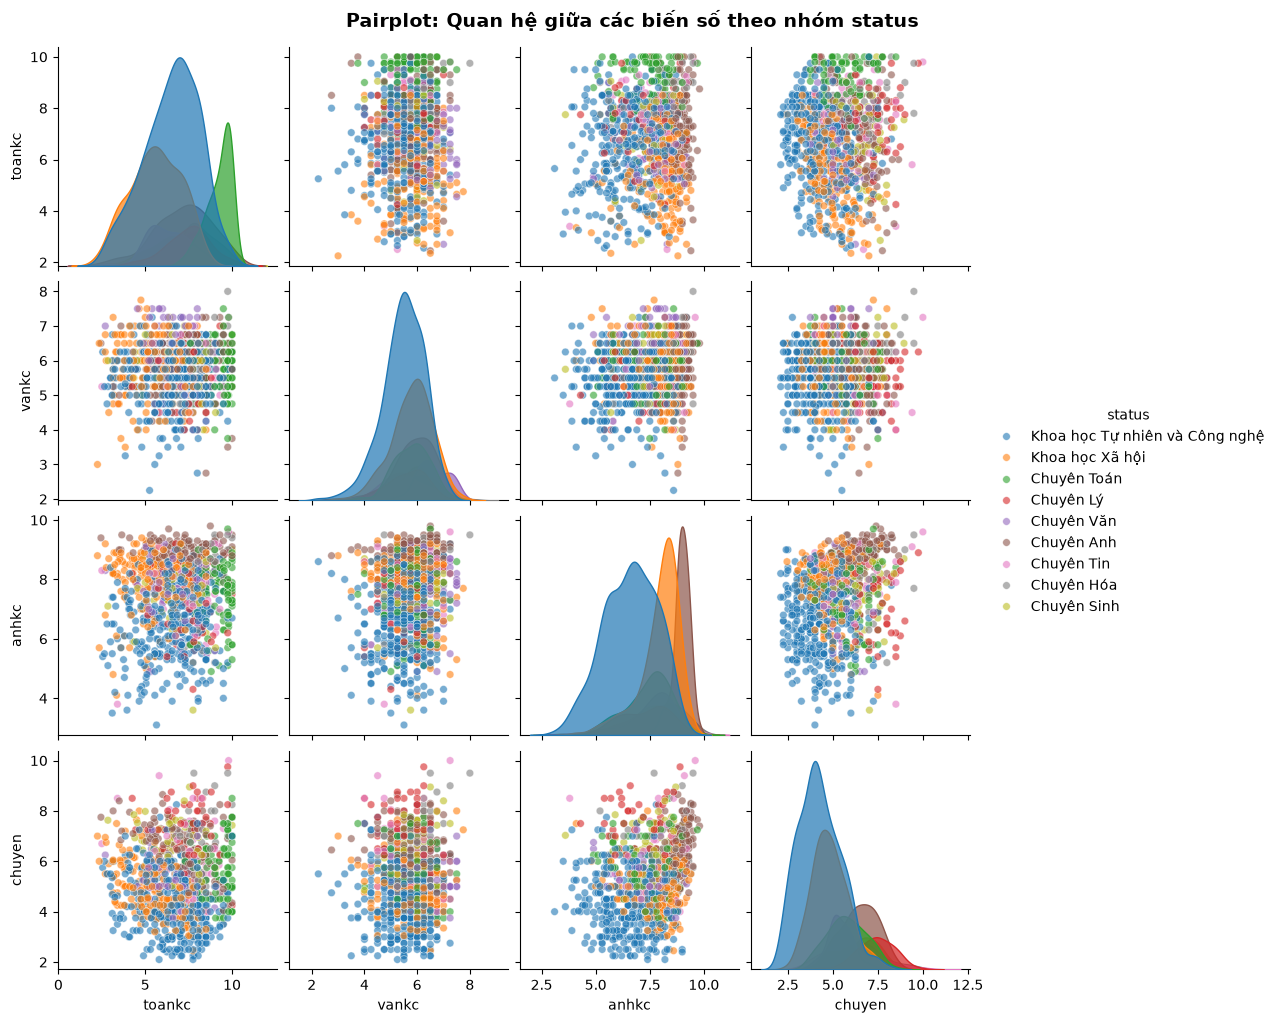

In [106]:
g = sns.pairplot(df, hue='status', vars=cols, 
                 diag_kind='kde', 
                 plot_kws={'alpha': 0.6, 's': 30},
                 diag_kws={'alpha': 0.7})
g.fig.suptitle('Pairplot: Quan hệ giữa các biến số theo nhóm status', 
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

Bất cập của một dataset phân loại ra quá nhiều nhóm là không đánh giá trực quan tốt được. Không thể tô màu theo species theo yêu cầu bài tập vì không có species :Đ. Ở dưới là pairplot 3 lớp chuyên toán văn anh để làm plot tương đối trực quan

status
Chuyên Anh     109
Chuyên Toán     92
Chuyên Văn      55
Name: count, dtype: int64


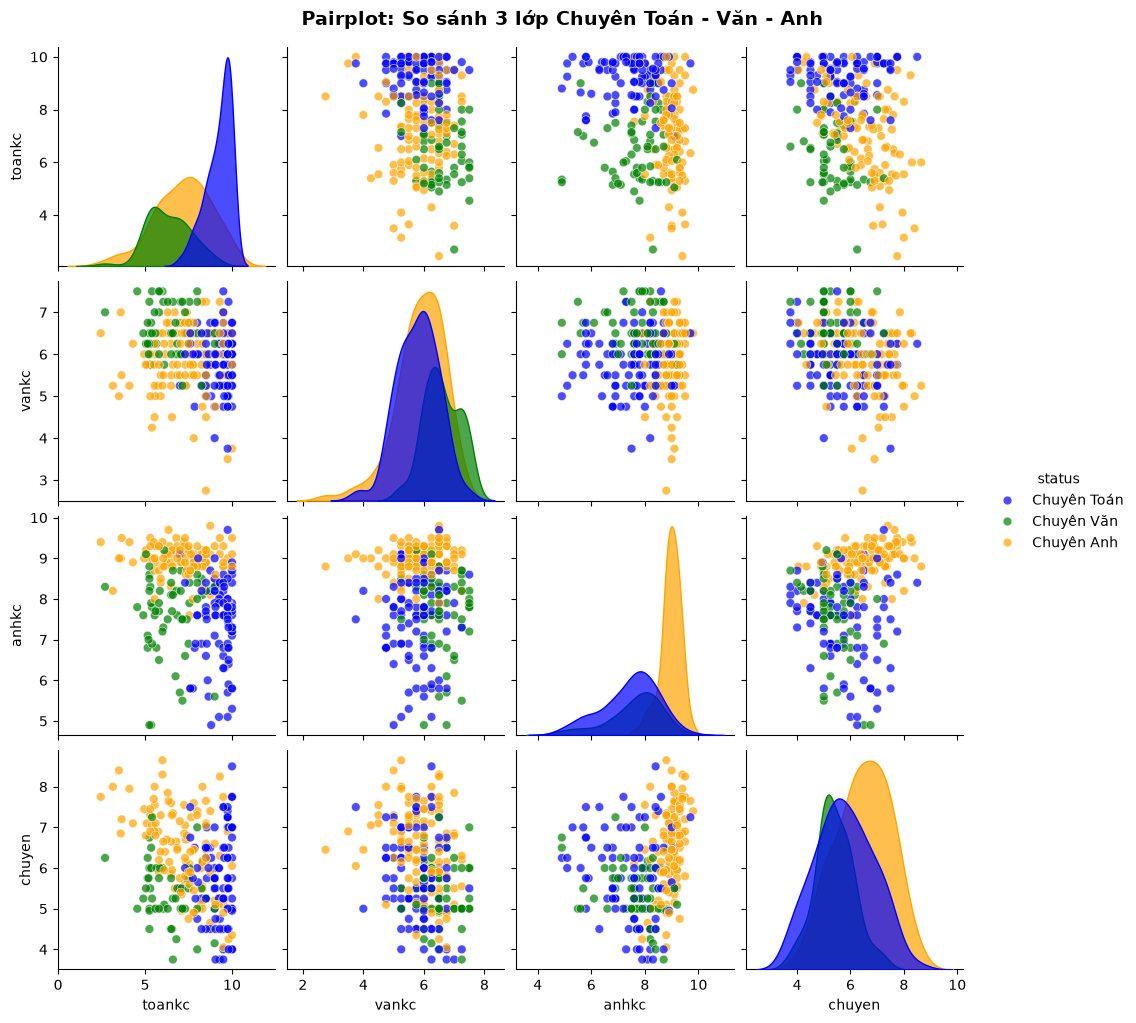

In [107]:
selected_classes = ['Chuyên Toán', 'Chuyên Văn', 'Chuyên Anh']
df_filtered = df[df['status'].isin(selected_classes)]

print(df_filtered['status'].value_counts())

# Vẽ pairplot
g = sns.pairplot(df_filtered, hue='status', vars=cols,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.7, 's': 40},
                 diag_kws={'alpha': 0.7},
                 palette={'Chuyên Toán': 'blue', 
                         'Chuyên Văn': 'green', 
                         'Chuyên Anh': 'orange'})
g.fig.suptitle('Pairplot: So sánh 3 lớp Chuyên Toán - Văn - Anh', 
               y=1.02, fontsize=14, fontweight='bold')
plt.show()

Nhận xét: Tương quan với môn chuyên, lớp toán và lớp anh rõ ràng hơn chứ không bị cloudy, ở đây thấy cluster (có thể gọi là trail) của lớp anh cao hơn lớp toán, chứng tỏ được tương quan điểm chuyên của anhkc-anh chuyên cao hơn toánkc-toán chuyên.
Tương quan với môn anh(bỏ lớp chuyên anh vì luôn là một cluster trên cùng ra) thì có thể thấy: chênh lệch điểm toán giữa lớp chuyên toán và văn vô cùng rõ ràng, còn chênh lệch điểm văn thì không lớn như vậy.
Tương quan vankc-toankc thì khá cloudy(không đánh giá trực quan tốt), nhưng những cái edge cao rõ ràng nhất vẫn thuộc về học sinh chuyên môn tương ứng.

In [108]:
P_pos_given_B = 0.99
P_pos_given_NB = 0.05
P_B = 0.01
P_pos = P_pos_given_B*P_B + P_pos_given_NB*(1-P_B)

P_B_given_pos = (P_pos_given_B * P_B) / P_pos

print(f"  - P(B) = {P_B} (tỉ lệ mắc bệnh trong dân số)")
print(f"  - P(+|B) = {P_pos_given_B} (độ nhạy - True Positive Rate)")
print(f"  - P(+|¬B) = {P_pos_given_NB} (tỉ lệ dương tính giả - False Positive Rate)")

print(f"  - P(+) = {P_pos:.4f} (xác suất xét nghiệm dương tính)")
print(f"  - P(B|+) = {P_B_given_pos:.4f} ({P_B_given_pos*100:.2f}%)")

print(f"  xác suất hậu nghiệm {P_B_given_pos*100:.2f}%.")

  - P(B) = 0.01 (tỉ lệ mắc bệnh trong dân số)
  - P(+|B) = 0.99 (độ nhạy - True Positive Rate)
  - P(+|¬B) = 0.05 (tỉ lệ dương tính giả - False Positive Rate)
  - P(+) = 0.0594 (xác suất xét nghiệm dương tính)
  - P(B|+) = 0.1667 (16.67%)
  xác suất hậu nghiệm 16.67%.


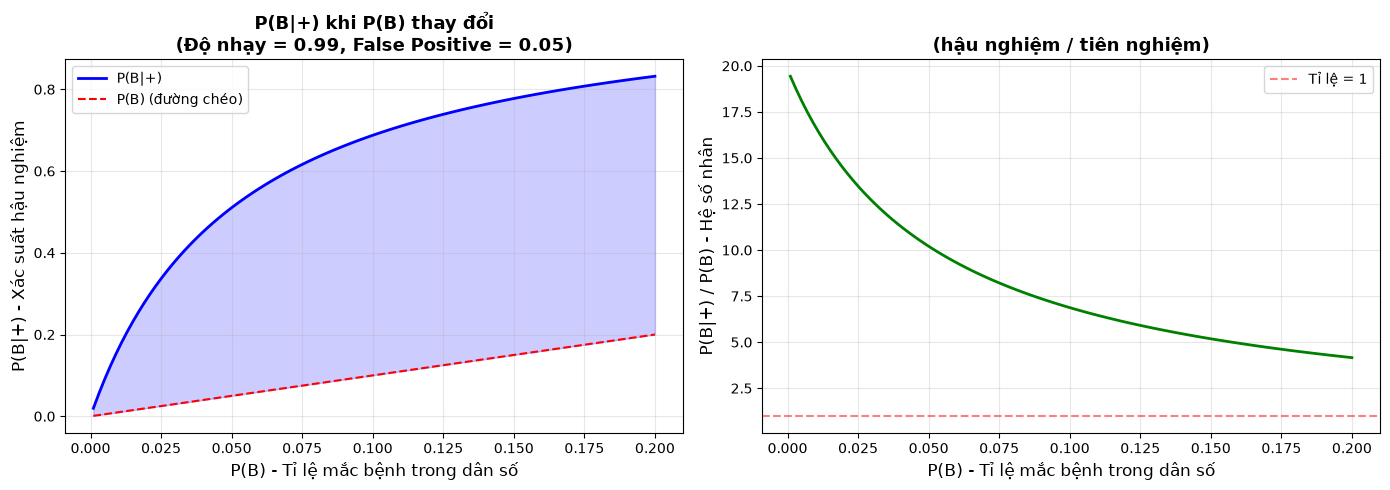

In [109]:
P_B_values = np.linspace(0.001, 0.2, 100)
P_B_given_pos_values = []

for p_b in P_B_values:
    p_pos = P_pos_given_B * p_b + P_pos_given_NB * (1 - p_b)
    p_b_given_pos = (P_pos_given_B * p_b) / p_pos
    P_B_given_pos_values.append(p_b_given_pos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Đồ thị chính
ax1.plot(P_B_values, P_B_given_pos_values, 'b-', linewidth=2, label='P(B|+)')
ax1.plot(P_B_values, P_B_values, 'r--', linewidth=1.5, label='P(B) (đường chéo)')
ax1.fill_between(P_B_values, P_B_given_pos_values, P_B_values, alpha=0.2, color='blue')

ax1.set_xlabel('P(B) - Tỉ lệ mắc bệnh trong dân số', fontsize=12)
ax1.set_ylabel('P(B|+) - Xác suất hậu nghiệm', fontsize=12)
ax1.set_title(f'P(B|+) khi P(B) thay đổi\n(Độ nhạy = {P_pos_given_B}, False Positive = {P_pos_given_NB})', 
             fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ratio_values = np.array(P_B_given_pos_values) / P_B_values
ax2.plot(P_B_values, ratio_values, 'g-', linewidth=2)
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Tỉ lệ = 1')
ax2.set_xlabel('P(B) - Tỉ lệ mắc bệnh trong dân số', fontsize=12)
ax2.set_ylabel('P(B|+) / P(B) - Hệ số nhân', fontsize=12)
ax2.set_title('(hậu nghiệm / tiên nghiệm)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Vì dân số khỏe mạnh thường chiếm tỉ lệ quá cao (tầm 0.99-0.999) nên tỉ lệ dương tính giả dù rất nhỏ (0.01) vẫn có thể lại cao hơn cả số người bị mắc bệnh.
Cho ví dụ với 10,000 người, P(B) 0.01, P(+| -B) = 0.05, P(+|B) = 0.99
-P(B) = 1% = có 100 người mắc bệnh
-Độ nhạy 99%
-False Positive 5% : 5% × 9,900 = 495 người khỏe bị dương tính giả
-Tổng dương tính: 99 + 495 = 594
-Xác suất thực sự mắc bệnh: 99/594 = 16.7%